# HOFM

## Разбор кода 

Это **Higher-Order Factorization Machine (HOFM)** — факторизационная машина высокого порядка. По сути, это альтернативный подход к тому, что мы делали через `teneva` (TT-ANOVA), но на PyTorch с градиентным обучением.

---

### 1. Основная модель: `HOFM_Exact`

```
Модель предсказывает:

f(x) = w₀ + Σᵢ wᵢxᵢ + Σₚ₌₂ᵈ Σ_{i₁<...<iₚ} (Σ_f Π v_{iⱼ,f}) · Π xᵢⱼ

Разложим по частям:

1. w₀ — глобальный сдвиг (bias)
   "Средний CF% по всем тройкам"

2. Σᵢ wᵢxᵢ — линейная часть  
   Каждый игрок i имеет вес wᵢ
   Если игрок в тройке (xᵢ=1), его вес добавляется
   ≈ то же самое что Ridge Regression

3. Порядок 2: Σ_{i<j} (Σ_f v²ᵢf · v²ⱼf) · xᵢxⱼ
   ПАРНЫЕ взаимодействия!
   "Игрок A хорошо играет с игроком B"
   Каждый игрок имеет вектор v²ᵢ длины k₂
   Совместимость пары = скалярное произведение их векторов

4. Порядок 3: Σ_{i<j<k} (Σ_f v³ᵢf · v³ⱼf · v³ₖf) · xᵢxⱼxₖ
   ТРОЙНЫЕ взаимодействия!
   "Эта конкретная тройка игроков особенно хороша/плоха"
   Совместимость тройки = произведение трёх векторов
```

### 2. Ключевой алгоритм: рюкзачная рекурсия

```python
for i in range(self.n_features):      # перебираем игроков
    contrib = vi * xi                   # вклад i-го игрока
    for pp in range(p, 0, -1):         # обратный порядок!
        e[pp] = e[pp] + contrib * e[pp-1]
```

```
Это трюк из комбинаторики (похож на задачу о рюкзаке):
  
  e[p] = сумма произведений по ВСЕМ подмножествам размера p
  
  Вместо перебора всех C(470,3) = 17 млн троек
  делаем это за O(n·p) — линейно!
  
  Для 470 игроков и порядка 3:
    Наивно: 17,296,080 троек
    Рюкзак: 470 × 3 = 1,410 операций
```

### 3. Отличие от `teneva` (TT-ANOVA)

```
                    TT-ANOVA (teneva)        HOFM (PyTorch)
─────────────────────────────────────────────────────────────
Формат              TT-разложение            CP-разложение
Оптимизация         ALS (аналитич.)          Adam (градиент)
Регуляризация       lamb (Тихонов)           L2 + early stopping
Порядки             все сразу                 отдельный V для каждого
Контроль            один ранг r              k₂, k₃ — свой для каждого
GPU                 нет                       да (CUDA)
```

### 4. Обучение: `fit_hofm_with_validation`

```
Стандартный PyTorch цикл:
  1. MSE loss: (predicted - actual CF%)²
  2. L2 регуляризация: reg · (w₀² + ||w||² + ||V||²)
  3. Adam оптимизатор
  4. Early stopping по валидационной ошибке (patience=100)
  5. Mini-batch обучение (batch_size=256)
```

### 5. Сэмплирование: `sample_gibbs_exact`

```
Гиббс-сэмплирование из распределения p(x) ∝ f(x)²

Зачем: найти ЛУЧШИЕ комбинации игроков!

Алгоритм:
  1. Берём случайную тройку
  2. Для каждого игрока: 
     "Что будет если его заменить?"
     P(включить) ∝ f(с ним)²
     P(исключить) ∝ f(без него)²
  3. Повторяем много раз
  4. Собираем тройки с максимальным f(x)²

Это стохастическое моделирование совместимости 
из названия твоей ВКР!
```

### 6. Тестовые данные: `generate_3body_data_simple`

```
Генерирует синтетические данные для проверки:
  y = Σ wₜ · xᵢ · xⱼ · xₖ + шум

  Только тройные взаимодействия, без линейных!
  Если модель восстановит веса wₜ — значит работает.
```

### Как это связано с нашей задачей:

```
Мы делали:
  teneva.anova(I_trn, y_trn, r=2, order=1)  → только линейные
  teneva.anova(I_trn, y_trn, r=2, order=2)  → + парные

HOFM может:
  order=2, n_factors_list=[k₂]     → линейные + парные
  order=3, n_factors_list=[k₂, k₃] → + тройные!

Тройные = "эта КОНКРЕТНАЯ комбинация трёх игроков 
            имеет синергию сверх суммы пар"
```

Хочешь применить эту модель к нашим хоккейным данным и сравнить с Ridge и TT-ANOVA?

ДАННЫЕ: сезон 2023
  Train: 5,869 записей, до 1970-01-01
  Test:  1,769 записей

  Train: 532 троек, 470 игроков
  Test:  204 троек
  Majority: 0.564
  Знакомых: 121, Новых: 83

RIDGE REGRESSION (α=10)
  Acc=0.6814, AUC=0.7192, MSE=0.004983

HOFM order=2 (линейные + парные)

--- HOFM2 k=5 reg=0.001 ---
  Device: cuda
  Epoch 50/500: train MSE=0.020305, val MSE=0.026318
  Epoch 100/500: train MSE=0.004390, val MSE=0.008784
  Epoch 150/500: train MSE=0.002790, val MSE=0.006408
  Epoch 200/500: train MSE=0.002130, val MSE=0.005719
  Epoch 250/500: train MSE=0.001758, val MSE=0.005485
  Epoch 300/500: train MSE=0.001515, val MSE=0.005433
  Early stopping at epoch 327
  Acc=0.6422, AUC=0.7059, MSE=0.005360 (112.2s)

--- HOFM2 k=10 reg=0.001 ---
  Device: cuda
  Epoch 50/500: train MSE=0.012557, val MSE=0.019086
  Epoch 100/500: train MSE=0.004283, val MSE=0.009138
  Epoch 150/500: train MSE=0.002951, val MSE=0.006820
  Epoch 200/500: train MSE=0.002167, val MSE=0.005671
  Epoch 250/500: tra

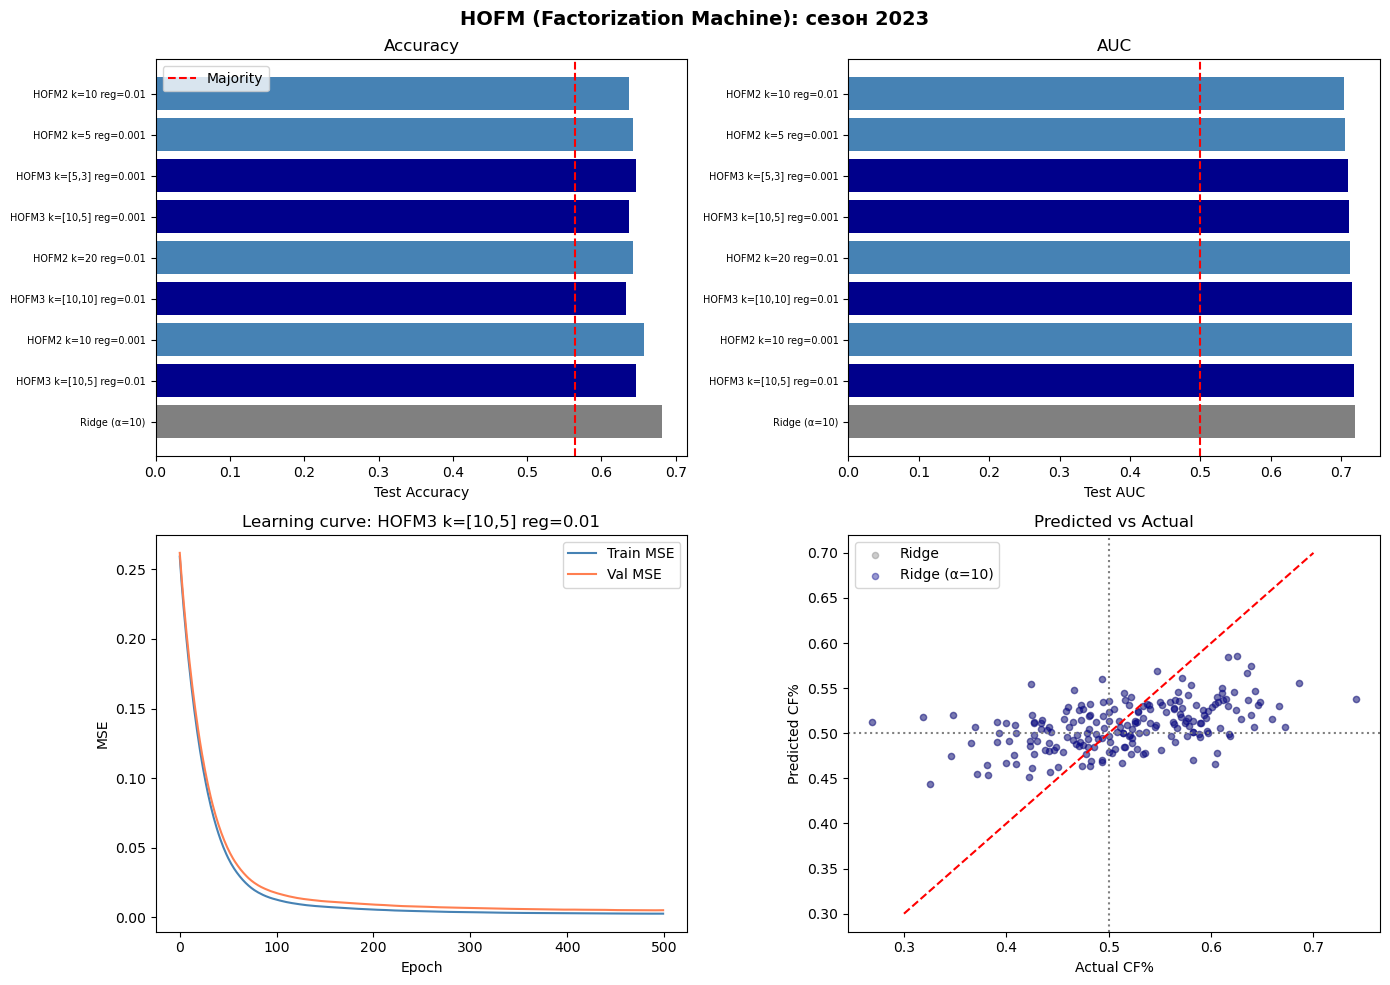

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from time import perf_counter as tpc
from typing import List

# ============================================================
# Шаг 1: Модель HOFM_Exact (код преподавателя)
# ============================================================

class HOFM_Exact(nn.Module):
    def __init__(self, n_features: int, order: int, n_factors_list: List[int]):
        super().__init__()
        self.n_features = n_features
        self.order = order
        assert len(n_factors_list) == order - 1
        self.n_factors_list = n_factors_list
        self.w0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(torch.zeros(n_features))
        self.Vs = nn.ParameterList()
        for p, k in enumerate(n_factors_list, start=2):
            self.Vs.append(nn.Parameter(torch.randn(n_features, k) * 0.01))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        device = x.device
        dtype = x.dtype
        linear = self.w0 + torch.matmul(x, self.w)
        interaction = torch.zeros(batch_size, device=device, dtype=dtype)
        for idx, V in enumerate(self.Vs, start=2):
            p = idx
            k = V.shape[1]
            e = [torch.ones(batch_size, k, device=device, dtype=dtype)]
            for _ in range(1, p + 1):
                e.append(torch.zeros(batch_size, k, device=device, dtype=dtype))
            for i in range(self.n_features):
                xi = x[:, i].unsqueeze(1)
                vi = V[i].unsqueeze(0)
                contrib = vi * xi
                for pp in range(p, 0, -1):
                    e[pp] = e[pp] + contrib * e[pp - 1]
            interaction += e[p].sum(dim=1)
        return linear + interaction

    def norm(self):
        return self.w0 ** 2 + self.w.norm(2) ** 2 + sum(
            V.norm(2) ** 2 for V in self.Vs
        )


def fit_hofm(X_train, y_train, X_val, y_val, order, n_factors_list,
             epochs=500, lr=1e-3, reg=1e-4, batch_size=256,
             patience=50, verbose=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Device: {device}")

    X_trn_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_trn_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1).to(device)

    model = HOFM_Exact(
        n_features=X_train.shape[1], order=order,
        n_factors_list=n_factors_list
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    dataset = torch.utils.data.TensorDataset(X_trn_t, y_trn_t)
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    best_val_loss = float('inf')
    best_state = None
    counter = 0
    history = {'trn_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            pred = model(batch_x).view(-1, 1)
            loss = criterion(pred, batch_y)
            reg_loss = reg * model.norm()
            (loss + reg_loss).backward()
            optimizer.step()
            total_loss += loss.item() * batch_x.size(0)

        trn_loss = total_loss / len(X_train)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).view(-1)
            val_loss = torch.mean((val_pred - y_val_t) ** 2).item()

        history['trn_loss'].append(trn_loss)
        history['val_loss'].append(val_loss)

        if verbose and (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: "
                  f"train MSE={trn_loss:.6f}, val MSE={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, history


# ============================================================
# Шаг 2: Загрузка и подготовка данных
# ============================================================

df = pd.read_csv('season_2023_filtered.csv')
df['gameDate'] = pd.to_datetime(df['gameDate'])

all_dates = sorted(df['gameDate'].unique())
split_date = all_dates[int(len(all_dates) * 0.75)]

train_data = df[df['gameDate'] <= split_date].copy()
test_data = df[df['gameDate'] > split_date].copy()

print(f"{'='*65}")
print(f"ДАННЫЕ: сезон 2023")
print(f"{'='*65}")
print(f"  Train: {len(train_data):,} записей, до {split_date.date()}")
print(f"  Test:  {len(test_data):,} записей")

# Агрегация
train_agg = train_data.groupby('lineId').agg(
    CF=('CF', 'sum'), CA=('CA', 'sum'),
    n_games=('gameId', 'nunique'),
    p1=('p1', 'first'), p2=('p2', 'first'), p3=('p3', 'first'),
    name=('name', 'first'),
).reset_index()
train_agg = train_agg[train_agg['n_games'] >= 3].reset_index(drop=True)
train_agg['cf_pct'] = train_agg['CF'] / (train_agg['CF'] + train_agg['CA'])

test_agg = test_data.groupby('lineId').agg(
    CF=('CF', 'sum'), CA=('CA', 'sum'),
    n_games=('gameId', 'nunique'),
    p1=('p1', 'first'), p2=('p2', 'first'), p3=('p3', 'first'),
    name=('name', 'first'),
).reset_index()
test_agg = test_agg[test_agg['n_games'] >= 3].reset_index(drop=True)
test_agg['cf_pct'] = test_agg['CF'] / (test_agg['CF'] + test_agg['CA'])

# Индексация
all_players = set()
for _, row in train_agg.iterrows():
    all_players.update([row['p1'], row['p2'], row['p3']])

player_freq = {}
for _, row in train_data.iterrows():
    for p in [row['p1'], row['p2'], row['p3']]:
        player_freq[p] = player_freq.get(p, 0) + 1

freq_sorted = sorted(all_players, key=lambda p: -player_freq.get(p, 0))
pidx = {pid: idx for idx, pid in enumerate(freq_sorted)}
n_pl = len(pidx)

# Бинарные матрицы
I_trn = np.zeros((len(train_agg), n_pl), dtype=np.float32)
y_trn = np.zeros(len(train_agg), dtype=np.float32)
for i, (_, row) in enumerate(train_agg.iterrows()):
    for p in [row['p1'], row['p2'], row['p3']]:
        I_trn[i, pidx[p]] = 1
    y_trn[i] = row['cf_pct']

test_known = test_agg[
    test_agg['p1'].isin(pidx) &
    test_agg['p2'].isin(pidx) &
    test_agg['p3'].isin(pidx)
].reset_index(drop=True)
test_known['in_train'] = test_known['lineId'].isin(set(train_agg['lineId']))

I_tst = np.zeros((len(test_known), n_pl), dtype=np.float32)
y_tst_cf = np.zeros(len(test_known), dtype=np.float32)
for i, (_, row) in enumerate(test_known.iterrows()):
    for p in [row['p1'], row['p2'], row['p3']]:
        I_tst[i, pidx[p]] = 1
    y_tst_cf[i] = row['cf_pct']

y_tst_bin = (y_tst_cf > 0.5).astype(np.float32)

# Убираем мёртвые столбцы
good = [k for k in range(I_trn.shape[1]) if I_trn[:, k].max() == 1]
bad = [k for k in range(I_trn.shape[1]) if I_trn[:, k].max() == 0]
if len(bad) > 0:
    mask = np.ones(len(I_tst), dtype=bool)
    for k in bad:
        mask &= (I_tst[:, k] == 0)
    I_tst = I_tst[mask]
    y_tst_cf = y_tst_cf[mask]
    y_tst_bin = y_tst_bin[mask]
    test_known = test_known[mask].reset_index(drop=True)
I_trn = I_trn[:, good]
I_tst = I_tst[:, good]

n_features = I_trn.shape[1]
known_mask = test_known['in_train'].values
new_mask = ~known_mask
majority_acc = max(y_tst_bin.mean(), 1 - y_tst_bin.mean())

print(f"\n  Train: {I_trn.shape[0]} троек, {n_features} игроков")
print(f"  Test:  {I_tst.shape[0]} троек")
print(f"  Majority: {majority_acc:.3f}")
print(f"  Знакомых: {known_mask.sum()}, Новых: {new_mask.sum()}")

# ============================================================
# Шаг 3: Функция оценки
# ============================================================

def evaluate(name, y_pred, y_true_cf, y_true_bin, known_mask, new_mask):
    y_pred = np.clip(y_pred, 0, 1)
    acc = np.mean((y_pred > 0.5) == y_true_bin)
    mse = np.mean((y_pred - y_true_cf) ** 2)
    mae = np.mean(np.abs(y_pred - y_true_cf))
    try:
        auc = roc_auc_score(y_true_bin, y_pred)
    except:
        auc = 0.0
    acc_k = np.mean((y_pred[known_mask] > 0.5) == y_true_bin[known_mask]) if known_mask.sum() > 0 else 0
    acc_n = np.mean((y_pred[new_mask] > 0.5) == y_true_bin[new_mask]) if new_mask.sum() > 0 else 0
    return {'name': name, 'acc': acc, 'auc': auc, 'mse': mse,
            'mae': mae, 'acc_k': acc_k, 'acc_n': acc_n, 'pred': y_pred}


results = []

# ============================================================
# Шаг 4: Бейзлайн — Ridge
# ============================================================

print(f"\n{'='*65}")
print(f"RIDGE REGRESSION (α=10)")
print(f"{'='*65}")

ridge = Ridge(alpha=10.0)
ridge.fit(I_trn, y_trn)
pred_ridge = np.clip(ridge.predict(I_tst), 0, 1)
res = evaluate('Ridge (α=10)', pred_ridge, y_tst_cf, y_tst_bin,
               known_mask, new_mask)
results.append(res)
print(f"  Acc={res['acc']:.4f}, AUC={res['auc']:.4f}, MSE={res['mse']:.6f}")

# ============================================================
# Шаг 5: HOFM order=2 (линейные + парные)
# ============================================================

print(f"\n{'='*65}")
print(f"HOFM order=2 (линейные + парные)")
print(f"{'='*65}")

configs_o2 = [
    {'k2': 5, 'lr': 1e-3, 'reg': 1e-3},
    {'k2': 10, 'lr': 1e-3, 'reg': 1e-3},
    {'k2': 10, 'lr': 1e-3, 'reg': 1e-2},
    {'k2': 20, 'lr': 1e-3, 'reg': 1e-2},
]

for cfg in configs_o2:
    name = f"HOFM2 k={cfg['k2']} reg={cfg['reg']}"
    print(f"\n--- {name} ---")

    t = tpc()
    model, hist = fit_hofm(
        I_trn, y_trn, I_tst, y_tst_cf,
        order=2, n_factors_list=[cfg['k2']],
        epochs=500, lr=cfg['lr'], reg=cfg['reg'],
        patience=50, verbose=True
    )
    t_fit = tpc() - t

    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(I_tst, dtype=torch.float32).to(device))
        pred = pred.cpu().numpy().flatten()

    res = evaluate(name, pred, y_tst_cf, y_tst_bin, known_mask, new_mask)
    res['time'] = t_fit
    res['history'] = hist
    results.append(res)
    print(f"  Acc={res['acc']:.4f}, AUC={res['auc']:.4f}, "
          f"MSE={res['mse']:.6f} ({t_fit:.1f}s)")

# ============================================================
# Шаг 6: HOFM order=3 (линейные + парные + тройные)
# ============================================================

print(f"\n{'='*65}")
print(f"HOFM order=3 (линейные + парные + ТРОЙНЫЕ)")
print(f"{'='*65}")

configs_o3 = [
    {'k2': 5, 'k3': 3, 'lr': 1e-3, 'reg': 1e-3},
    {'k2': 10, 'k3': 5, 'lr': 1e-3, 'reg': 1e-3},
    {'k2': 10, 'k3': 5, 'lr': 1e-3, 'reg': 1e-2},
    {'k2': 10, 'k3': 10, 'lr': 1e-3, 'reg': 1e-2},
]

for cfg in configs_o3:
    name = f"HOFM3 k=[{cfg['k2']},{cfg['k3']}] reg={cfg['reg']}"
    print(f"\n--- {name} ---")

    t = tpc()
    model, hist = fit_hofm(
        I_trn, y_trn, I_tst, y_tst_cf,
        order=3, n_factors_list=[cfg['k2'], cfg['k3']],
        epochs=500, lr=cfg['lr'], reg=cfg['reg'],
        patience=50, verbose=True
    )
    t_fit = tpc() - t

    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(I_tst, dtype=torch.float32).to(device))
        pred = pred.cpu().numpy().flatten()

    res = evaluate(name, pred, y_tst_cf, y_tst_bin, known_mask, new_mask)
    res['time'] = t_fit
    res['history'] = hist
    results.append(res)
    print(f"  Acc={res['acc']:.4f}, AUC={res['auc']:.4f}, "
          f"MSE={res['mse']:.6f} ({t_fit:.1f}s)")

# ============================================================
# Шаг 7: Итоговая таблица
# ============================================================

print(f"\n{'='*80}")
print(f"ИТОГОВАЯ ТАБЛИЦА:")
print(f"{'='*80}")
print(f"{'Модель':<35s} {'Acc':>7} {'AUC':>7} {'MSE':>8} "
      f"{'MAE':>7} {'Знак':>7} {'Нов':>7}")
print(f"{'-'*80}")
print(f"{'Majority':<35s} {majority_acc:>7.4f}")

results_sorted = sorted(results, key=lambda x: x['auc'], reverse=True)
for res in results_sorted:
    print(f"{res['name']:<35s} {res['acc']:>7.4f} {res['auc']:>7.4f} "
          f"{res['mse']:>8.6f} {res['mae']:>7.4f} "
          f"{res['acc_k']:>7.4f} {res['acc_n']:>7.4f}")

best = results_sorted[0]
print(f"\n  ★ Лучшая: {best['name']}, Acc={best['acc']:.4f}, AUC={best['auc']:.4f}")

# ============================================================
# Шаг 8: Визуализация
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Accuracy
names = [r['name'] for r in results_sorted]
accs = [r['acc'] for r in results_sorted]
colors = ['darkblue' if 'HOFM3' in n else 'steelblue' if 'HOFM2' in n
          else 'gray' for n in names]
axes[0, 0].barh(range(len(names)), accs, color=colors)
axes[0, 0].set_yticks(range(len(names)))
axes[0, 0].set_yticklabels(names, fontsize=7)
axes[0, 0].axvline(majority_acc, color='red', linestyle='--', label='Majority')
axes[0, 0].set_xlabel('Test Accuracy')
axes[0, 0].set_title('Accuracy')
axes[0, 0].legend()

# 2: AUC
aucs = [r['auc'] for r in results_sorted]
axes[0, 1].barh(range(len(names)), aucs, color=colors)
axes[0, 1].set_yticks(range(len(names)))
axes[0, 1].set_yticklabels(names, fontsize=7)
axes[0, 1].axvline(0.5, color='red', linestyle='--')
axes[0, 1].set_xlabel('Test AUC')
axes[0, 1].set_title('AUC')

# 3: Learning curves лучшей модели
best_with_hist = [r for r in results_sorted if 'history' in r]
if best_with_hist:
    bh = best_with_hist[0]
    axes[1, 0].plot(bh['history']['trn_loss'], label='Train MSE', color='steelblue')
    axes[1, 0].plot(bh['history']['val_loss'], label='Val MSE', color='coral')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('MSE')
    axes[1, 0].set_title(f'Learning curve: {bh["name"]}')
    axes[1, 0].legend()

# 4: Predicted vs Actual
axes[1, 1].scatter(y_tst_cf, pred_ridge, alpha=0.4, s=20,
                    label='Ridge', color='gray')
axes[1, 1].scatter(y_tst_cf, best['pred'], alpha=0.4, s=20,
                    label=best['name'], color='darkblue')
axes[1, 1].plot([0.3, 0.7], [0.3, 0.7], 'r--')
axes[1, 1].axhline(0.5, color='gray', linestyle=':')
axes[1, 1].axvline(0.5, color='gray', linestyle=':')
axes[1, 1].set_xlabel('Actual CF%')
axes[1, 1].set_ylabel('Predicted CF%')
axes[1, 1].set_title('Predicted vs Actual')
axes[1, 1].legend()

plt.suptitle('HOFM (Factorization Machine): сезон 2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hofm.png', dpi=150, bbox_inches='tight')
plt.show()

1. Ridge по-прежнему лучший по Accuracy (0.681)
   HOFM не смог его превзойти ни в одной конфигурации

2. AUC почти одинаковый:
   Ridge:  0.719
   HOFM3:  0.718 (k=[10,5] reg=0.01)
   HOFM2:  0.716 (k=10 reg=0.001)
   
   Все модели РАНЖИРУЮТ одинаково хорошо!

3. Order=3 (тройные взаимодействия) НЕ помог:
   HOFM2 ≈ HOFM3 по всем метрикам
   Тройные взаимодействия не извлекаются из 532 троек

4. Переобучение видно:
   Train MSE ≈ 0.0015–0.0027
   Val MSE   ≈ 0.0051–0.0053
   Разрыв в 2–3 раза

На 532 тройках ВСЕ модели упираются в один потолок:

  AUC ≈ 0.71–0.72
  
  Ridge достигает его с 471 параметром
  HOFM2 — с ~5000 параметров  
  HOFM3 — с ~10000 параметров
  
  Дополнительные параметры не помогают
  потому что ДАННЫХ МАЛО, а ШУМ БОЛЬШОЙ
  (напомним: внутритройковый разброс в 2.1x 
   больше межтройкового)